# 실습 7: 학습용과 시험용으로 나누기
- 상황: 아직 검사하지 않은 흐름의 결과를 맞혀보려 한다
- 목표: 답을 아는 기록과 모르는 척할 기록을 나눈다

## Step 0. 정제본 불러오기

In [1]:
import pandas as pd

df = pd.read_csv('../../day02/lab06_clean-dataset/results/secom_clean.csv')

print('행 수:', df.shape[0])
print('열 수:', df.shape[1])

print()
print('result 값별 건수:')
print(df['result'].value_counts())

행 수: 1567
열 수: 51

result 값별 건수:
result
양품    1463
불량     104
Name: count, dtype: int64


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 모델을 만들 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 지도학습 | 답이 붙어 있는 기록으로 규칙을 찾게 하는 방식. 우리 데이터의 검사 결과가 그 답이다 |
| 분류 | 둘 중 어느 쪽인지 맞히는 문제. 양품이냐 불량이냐 |
| 학습용 | 답을 보여주고 규칙을 찾게 할 몫 |
| 시험용 | 답을 숨겨두고 실력을 재는 데 쓸 몫 |
| 과적합 | 학습용을 통째로 외워버려 처음 보는 기록은 못 맞히는 상태 |
| 일반화 | 그 반대. 처음 보는 기록에도 통하는 상태. 우리가 원하는 것 |
| 클래스 불균형 | 한쪽이 드문 상태. 여기서는 불량이 약 6.6%뿐이다 |
| 층화추출 | 나눌 때 드문 쪽 비율을 양쪽에 똑같이 맞춰주는 방식 |

## Step 2. 남은 빈칸 채우기

In [2]:
sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

# 채우기 전 — 빈칸이 있는 센서 열 개수와, 전체 센서 칸 중 빈칸 비율
빈칸_있는_열_수 = df[sensor_cols].isna().any().sum()
전체_빈칸_비율 = df[sensor_cols].isna().sum().sum() / df[sensor_cols].size * 100

print('빈칸이 있는 센서 열:', 빈칸_있는_열_수, '개')
print('전체 센서 칸 중 빈칸 비율:', round(전체_빈칸_비율, 4), '%')

# result 열은 건드리지 않고, 센서 열만 각 열의 중앙값으로 채운다
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

# 채운 뒤 다시 확인
print('\n채운 뒤 센서 열 빈칸 개수:', df[sensor_cols].isna().sum().sum())

빈칸이 있는 센서 열: 48 개
전체 센서 칸 중 빈칸 비율: 1.9643 %

채운 뒤 센서 열 빈칸 개수: 0


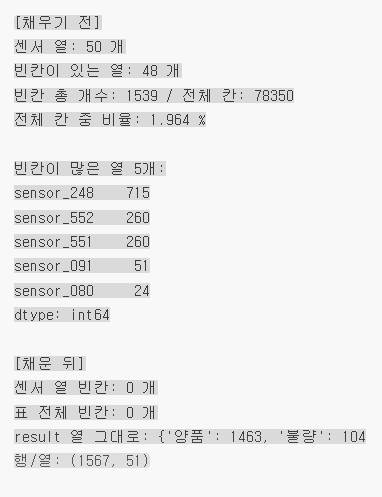

## Step 3. 정답표를 숫자로 바꾸기

In [3]:
# result 열은 "양품"·"불량"이라는 글자다. 모델은 글자로 학습하지 못한다.
# == 로 비교하면 참/거짓이 되고, astype(int)가 참을 1, 거짓을 0으로 바꾼다
df["불량여부"] = (df["result"] == "불량").astype(int)

# 1의 개수가 앞에서 본 불량 건수와 같아야 한다
print(df["불량여부"].value_counts())

불량여부
0    1463
1     104
Name: count, dtype: int64


## Step 4. 입력과 정답으로 가르기

In [4]:
# 입력 - 센서 열만. result 와 불량여부는 절대 들어가면 안 된다
센서열 = [c for c in df.columns if c.startswith("sensor_")]
X = df[센서열]

# 정답 - 맞혀야 할 것
y = df["불량여부"]

print("입력:", X.shape)
print("정답:", y.shape)

입력: (1567, 50)
정답: (1567,)


## Step 5. 학습용과 시험용으로 나누기

In [5]:
# train_test_split - 표를 학습용과 시험용 두 몫으로 갈라준다
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 시험용으로 떼어둘 비율 (20%)
    random_state=42,      # 무작위로 섞되, 다시 실행해도 같게 나오도록 고정
    stratify=y            # 불량 비율을 양쪽에 똑같이 맞춰서 나눈다
)

print("학습용:", X_train.shape)
print("시험용:", X_test.shape)

학습용: (1253, 50)
시험용: (314, 50)


STEP6. 나눈 결과를 한 표로 확인

### 문법 노트 - 나누기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| train_test_split(X, y) | 입력과 정답을 같은 기준으로 두 몫씩 갈라준다 | 답을 숨겨둔 몫이 있어야 실력을 잰다 |
| test_size=0.2 | 시험용으로 뗄 비율 | 20%면 300건 정도 남는다 |
| random_state=42 | 섞는 방식을 고정 | 안 넣으면 돌릴 때마다 결과가 달라져 비교가 안 된다 |
| stratify=y | 정답 비율을 양쪽에 맞춰 나눈다 | 불량이 6.6%뿐이라 안 맞추면 한쪽에 몰린다 |

**돌려주는 것이 네 덩어리인 순서에 주의.**<br>
X_train, X_test, y_train, y_test 순서다. 입력 둘이 먼저, 정답 둘이 나중.<br>
순서를 바꿔 받으면 오류 없이 실행되면서 결과만 이상해진다.

In [6]:
# X_train/X_test는 입력(센서 값)만 있고 정답이 없지만, train_test_split이 인덱스를 그대로 맞춰 나눴기 때문에
# 같은 행에 대한 정답은 y_train/y_test에서 그대로 가져올 수 있다
정리표 = pd.DataFrame({
    '행 수': [len(X_train), len(X_test), len(y_train), len(y_test)],
    '불량 건수': [y_train.sum(), y_test.sum(), y_train.sum(), y_test.sum()],
}, index=['X_train', 'X_test', 'y_train', 'y_test'])

정리표['불량 비율(%)'] = (정리표['불량 건수'] / 정리표['행 수'] * 100).round(2)
정리표['원본 전체 불량 비율(%)'] = round(df['불량여부'].mean() * 100, 2)

정리표

,행 수,불량 건수,불량 비율(%),원본 전체 불량 비율(%)
X_train,1253,83,6.62,6.64
X_test,314,21,6.69,6.64
y_train,1253,83,6.62,6.64
y_test,314,21,6.69,6.64


[Step 5 결과]<br>
X_train : [1253]행, 불량 [83]건, 불량 비율 [6.62]%<br>
X_test  : [314]행, 불량 [21]건, 불량 비율 [6.69]%<br>
y_train : [1253]행, 불량 [83]건, 불량 비율 [6.62]%<br>
y_test  : [314]행, 불량 [21]건, 불량 비율 [6.69]%<br>
원본 전체 불량 비율 : [6.64]%<br>
→ stratify=y 덕분에 학습용·시험용 불량 비율이 원본과 [거의 같게] 유지됐다

[나눈 결과]<br>
학습용 : [1253]건 (불량 [83]건, [6.62]%)<br>
시험용 : [314]건 (불량 [21]건, [6.69]%)<br>
전체   : [1567]건 (불량 [104]건, [6.64]%)<br>
시험용 불량이 [21]건뿐이다.

## Step 7. 첫 예측 한 번 돌려보기

In [7]:
# 가장 기본적인 분류 모델 하나 — 로지스틱 회귀
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('1. 예측 결과 개수:', len(y_pred))
print('2. 불량이라고 예측한 건수:', int((y_pred == 1).sum()))
print('3. 시험용의 실제 불량 건수:', int(y_test.sum()))

1. 예측 결과 개수: 314
2. 불량이라고 예측한 건수: 0
3. 시험용의 실제 불량 건수: 21


c:\Users\13sx0\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


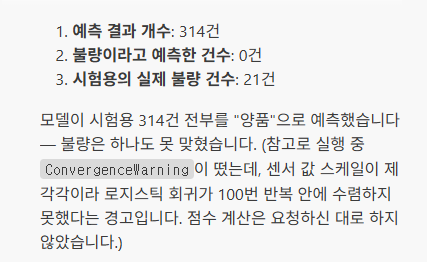

---
## 직접 해보기 (도전) - 비율을 안 맞추고 나누면

- 상황: stratify 를 넣어야 한다고 배웠지만, 안 넣으면 실제로 얼마나 달라지는지는 모른다
- 할 일: stratify 없이 여러 번 나눠보고 시험용 불량 건수가 얼마나 흔들리는지 본다
- 결과물: 다섯 줄짜리 비교표 1개

In [8]:
# 앞에서 만든 X_train/X_test/y_train/y_test는 건드리지 않고, 비교용으로 새로 나눠본다
비교_행들 = []
for rs in range(5):
    # stratify=y 를 넣은 경우
    _, X시험_유, _, y시험_유 = train_test_split(X, y, test_size=0.2, random_state=rs, stratify=y)
    # stratify를 뺀 경우
    _, X시험_무, _, y시험_무 = train_test_split(X, y, test_size=0.2, random_state=rs)

    비교_행들.append({
        'random_state': rs,
        '불량 건수 (stratify O)': int(y시험_유.sum()),
        '불량 비율(%) (stratify O)': round(y시험_유.mean() * 100, 2),
        '불량 건수 (stratify X)': int(y시험_무.sum()),
        '불량 비율(%) (stratify X)': round(y시험_무.mean() * 100, 2),
    })

stratify_비교표 = pd.DataFrame(비교_행들).set_index('random_state')
stratify_비교표

,불량 건수 (stratify O),불량 비율(%) (stratify O),불량 건수 (stratify X),불량 비율(%) (stratify X)
random_state,,,,
0,21,6.69,13,4.14
1,21,6.69,20,6.37
2,21,6.69,20,6.37
3,21,6.69,19,6.05
4,21,6.69,26,8.28


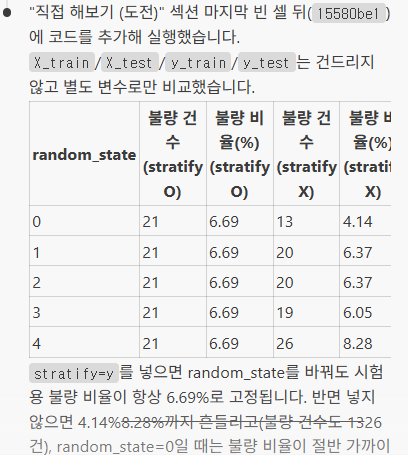

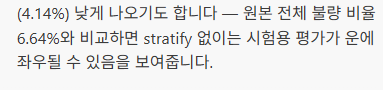

### stratify 있음 vs 없음 (시험용 불량 건수와 비율)

| random_state | 있음 | 없음 |
|---|---|---|
| 0 | [21] (6.69%) | [13] (4.14%) |
| 1 | [21] (6.69%) | [20] (6.37%) |
| 2 | [21] (6.69%) | [20] (6.37%) |
| 3 | [21] (6.69%) | [19] (6.05%) |
| 4 | [21] (6.69%) | [26] (8.28%) |

흔들린 폭 : 있음 [21]~[21]건 / 없음 [13]~[26]건